In [28]:
import mujoco
import pyrender
import numpy as np
import gymnasium
import skvideo.io
from base64 import b64encode
from IPython.display import HTML
from gymnasium.envs.registration import register

In [29]:
path = './ManiSkill-UR10e-main/ur10e.xml'
env_id = 'Environment'

In [30]:
register(
    id='Environment',
    entry_point='env:Environment',
    kwargs={
        'model_path': path
    }
)

/home/roboticlab/miniconda3/envs/Max_env/lib/python3.10/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment Environment already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [31]:
env = gymnasium.make(env_id, model_path=path, render_mode='rgb_array', camera_id=5)

In [32]:
# Turning off the shadows
# env.data.model.light_castshadow[0] = 0

/home/roboticlab/miniconda3/envs/Max_env/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float64, actual type: int64
  logger.warn(
/home/roboticlab/miniconda3/envs/Max_env/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:130: UserWarning: WARN: The obs returned by the `step()` method was expecting a numpy array, actual type: <class 'list'>
  logger.warn(
/home/roboticlab/miniconda3/envs/Max_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


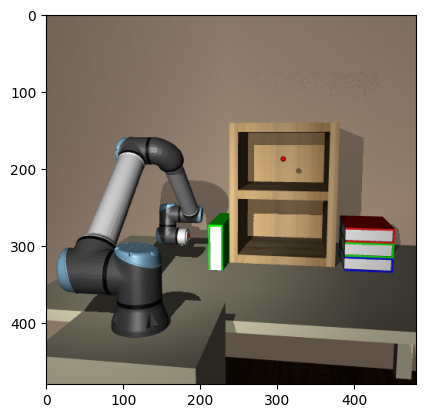

In [33]:
env.reset()
import matplotlib.pyplot as plt
env.step(np.zeros(env.action_space.shape))
plt.imshow(env.render())

In [34]:
# The generated actuator angles
points = np.load('angles.npy')

In [35]:
# Running the simulation
env = gymnasium.make(env_id, model_path=path, render_mode='rgb_array', camera_id=5)
# env.data.model.light_castshadow[0] = 0
env.reset()
frames = []

for act in points:
    for _ in range(5):
        env.step(act)
        frame = env.render()
        frames.append(frame)

In [36]:
skvideo.io.vwrite("output.mp4", np.asarray(frames))

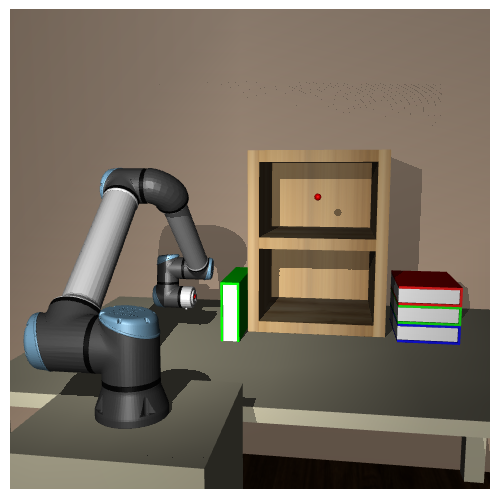

In [37]:
plt.imshow(frames[0])
plt.gca().set_axis_off()
plt.subplots_adjust(top = 1, bottom = 0, right = 1, left = 0,
            hspace = 0, wspace = 0)
plt.margins(0,0)
plt.gca().xaxis.set_major_locator(plt.NullLocator())
plt.gca().yaxis.set_major_locator(plt.NullLocator())
plt.savefig("start_frame.jpg", bbox_inches = 'tight',
    pad_inches = 0)

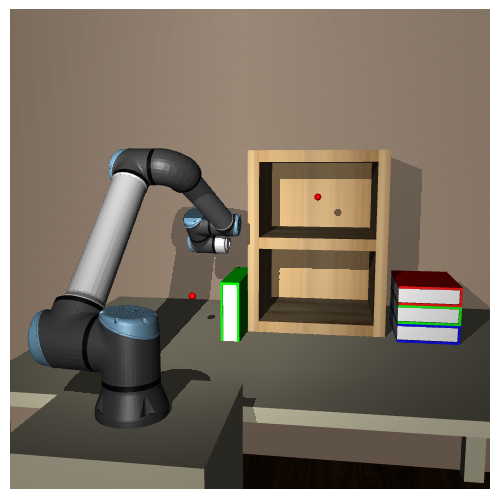

In [38]:
plt.imshow(frames[28])
plt.gca().set_axis_off()
plt.subplots_adjust(top = 1, bottom = 0, right = 1, left = 0,
            hspace = 0, wspace = 0)
plt.margins(0,0)
plt.gca().xaxis.set_major_locator(plt.NullLocator())
plt.gca().yaxis.set_major_locator(plt.NullLocator())
plt.savefig("middle_frame.jpg", bbox_inches = 'tight',
    pad_inches = 0)

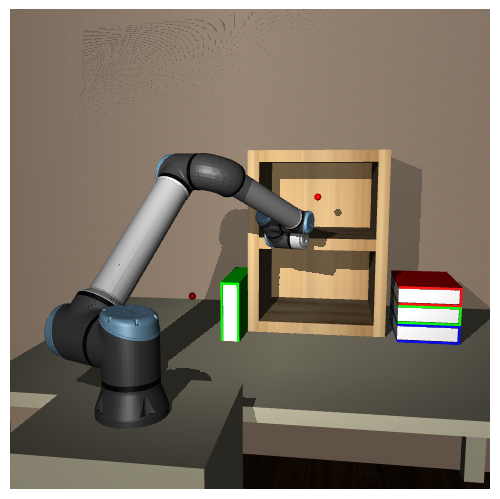

In [39]:
plt.imshow(frames[54])
plt.gca().set_axis_off()
plt.subplots_adjust(top = 1, bottom = 0, right = 1, left = 0,
            hspace = 0, wspace = 0)
plt.margins(0,0)
plt.gca().xaxis.set_major_locator(plt.NullLocator())
plt.gca().yaxis.set_major_locator(plt.NullLocator())
plt.savefig("goal_frame.jpg", bbox_inches = 'tight',
    pad_inches = 0)